## **1. Load CSV File**

In [88]:
import pandas as pd

df = pd.read_csv("flipkart_laptops_raw.csv")

print(df.shape)
print(df.columns.tolist())
print(df.head())
print(df.info())
print(df.isnull().sum())

(984, 11)
['Name', 'Price', 'Rating', 'Total_Reviews', 'Processor', 'RAM', 'Operating_System', 'Storage', 'Display_Size', 'Microsoft_365_Subscription', 'Warranty']
                                                Name    Price  Rating  \
0  Samsung Galaxy Book4 Metal Intel Core i3 13th ...  ₹49,990     4.4   
1  Apple Macbook Neo A18 Pro(2026) A18 Pro - (8 G...  ₹82,990     4.7   
2  Acer Aspire 14 AMD Ryzen 3 3200U - (8 GB/256 G...  ₹29,990     NaN   
3  DELL 15 (Previouly Inspiron) AMD Ryzen 5 Quad ...  ₹52,064     4.2   
4  HP 15 (i5 14th Gen) Intel Core 5 120U - (24 GB...  ₹81,691     4.2   

   Total_Reviews                           Processor                      RAM  \
0  1,276 Reviews  Intel Core i3 Processor (13th Gen)         8 GB LPDDR4X RAM   
1     82 Reviews             Apple A18 Pro Processor  8 GB Unified Memory RAM   
2            NaN               AMD Ryzen 3 Processor            8 GB DDR4 RAM   
3      1 Reviews     AMD Ryzen 5 Quad Core Processor          8 GB LPDDR5

In [89]:
df.describe(include="all")

,Name,Price,Rating,Total_Reviews,Processor,RAM,Operating_System,Storage,Display_Size,Microsoft_365_Subscription,Warranty
count,984,981,890.000000,890,984,984,984,960,984,272,798
unique,503,359,NaN,149,76,29,15,10,37,56,51
top,ASUS Vivobook 14 (2025) with Office 2024 + M36...,"₹72,990",NaN,82 Reviews,Apple A18 Pro Processor,16 GB DDR5 RAM,Windows 11 Home Operating System,512 GB SSD,39.62 cm (15.6 Inch) Display,Microsoft Office Home 2024 (Lifetime Validity ...,1 Year Onsite Warranty
freq,79,112,NaN,148,147,160,276,743,298,85,386
mean,NaN,NaN,4.342247,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.343756,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,2.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.200000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **1. Data-Cleaning**
### **A. Remove duplicate products**

In [90]:
df.duplicated().sum()

np.int64(443)

In [91]:
df["Name"].duplicated().sum()

np.int64(481)

In [92]:
print("Rows:", len(df))

print("Exact duplicates:", df.duplicated().sum())

print("Unique names:", df["Name"].nunique())

print("Duplicate names:", df["Name"].duplicated().sum())


Rows: 984
Exact duplicates: 443
Unique names: 503
Duplicate names: 481


In [93]:
df = df.drop_duplicates()

In [94]:
print("Rows after removing exact duplicates:", len(df))
print("Exact duplicates:", df.duplicated().sum())
print("Unique names:", df["Name"].nunique())
print("Duplicate names:", df["Name"].duplicated().sum())

Rows after removing exact duplicates: 541
Exact duplicates: 0
Unique names: 503
Duplicate names: 38


In [95]:
duplicate_names = df[df["Name"].duplicated(keep=False)].sort_values("Name")

print(duplicate_names.shape)
duplicate_names.head(20)

(72, 11)


,Name,Price,Rating,Total_Reviews,Processor,RAM,Operating_System,Storage,Display_Size,Microsoft_365_Subscription,Warranty
239,ASUS Chromebook Intel Celeron Dual Core N4500 ...,"₹23,990",3.8,272 Reviews,Intel Celeron Dual Core Processor,8 GB LPDDR4X RAM,64 bit Chrome Operating System,NaN,39.62 cm (15.6 Inch) Display,NaN,1 Year Onsite Warranty
308,ASUS Chromebook Intel Celeron Dual Core N4500 ...,"₹24,891",3.8,272 Reviews,Intel Celeron Dual Core Processor,8 GB LPDDR4X RAM,64 bit Chrome Operating System,NaN,39.62 cm (15.6 Inch) Display,NaN,1 Year Onsite Warranty
819,ASUS ExpertBook B15 Intel Core i3 12th Gen 121...,"₹48,991",NaN,NaN,Intel Core i3 Processor (12th Gen),8 GB DDR4 RAM,Windows 11 Operating System,512 GB SSD,39.62 cm (15.6 inch) Display,NaN,1 Year Onsite Warranty
975,ASUS ExpertBook B15 Intel Core i3 12th Gen 121...,"₹62,899",4.3,49 Reviews,Intel Core i3 Processor (12th Gen),8 GB DDR4 RAM,Windows 11 Operating System,512 GB SSD,39.62 cm (15.6 Inch) Display,NaN,1 Year Onsite Warranty
78,ASUS ExpertBook P3 AI PC with 1 Yr ADP Intel C...,"₹87,925",4.3,18 Reviews,Intel Core Ultra 5 Processor,16 GB DDR5 RAM,Windows 11 Home Operating System,512 GB SSD,35.56 cm (14 inch) Display,Microsoft Office Home 2024 + Microsoft 365 Basic,NaN
112,ASUS ExpertBook P3 AI PC with 1 Yr ADP Intel C...,"₹87,851",4.3,18 Reviews,Intel Core Ultra 5 Processor,16 GB DDR5 RAM,Windows 11 Home Operating System,512 GB SSD,40.64 cm (16 inch) Display,Microsoft Office Home 2024 + Microsoft 365 Basic,NaN
164,ASUS ExpertBook Ultra Copilot+ PC Intel Core U...,"₹2,39,990",4.9,6 Reviews,Intel Core Ultra X7 Processor,32 GB LPDDR5X RAM,Windows 11 Home Operating System,1 TB SSD,35.56 cm (14 inch) Touchscreen Display,Microsoft Office Home 2024 + Microsoft 365 Basic,NaN
584,ASUS ExpertBook Ultra Copilot+ PC Intel Core U...,"₹2,72,990",4.9,6 Reviews,Intel Core Ultra X7 Processor,32 GB LPDDR5X RAM,Windows 11 Home Operating System,1 TB SSD,35.56 cm (14 inch) Touchscreen Display,Microsoft Office Home 2024 + Microsoft 365 Basic,NaN
529,ASUS Expertbook P1 with 1 Yr ADP(i3 14th Gen) ...,"₹66,447",4.3,660 Reviews,Intel Core 3 Processor (13th Gen),16 GB DDR5 RAM,64 bit Windows 11 Home Operating System,512 GB SSD,39.62 cm (15.6 Inch) Display,Included Software- Microsoft Office Home 2024(...,1 Year Onsite Warranty
535,ASUS Expertbook P1 with 1 Yr ADP(i3 14th Gen) ...,"₹54,990",4.3,660 Reviews,Intel Core 3 Processor (13th Gen),16 GB DDR5 RAM,Windows 11 Home Operating System,512 GB SSD,35.56 cm (14 Inch) Display,Included Software- Microsoft Office Home 2024(...,1 Year Onsite Warranty


### **B. Create a Brand column**

In [96]:
df["Brand"] = df["Name"].str.split().str[0]

In [97]:
print(df[["Name", "Brand"]].head(20))

                                                 Name     Brand
0   Samsung Galaxy Book4 Metal Intel Core i3 13th ...   Samsung
1   Apple Macbook Neo A18 Pro(2026) A18 Pro - (8 G...     Apple
2   Acer Aspire 14 AMD Ryzen 3 3200U - (8 GB/256 G...      Acer
3   DELL 15 (Previouly Inspiron) AMD Ryzen 5 Quad ...      DELL
4   HP 15 (i5 14th Gen) Intel Core 5 120U - (24 GB...        HP
5   Apple Macbook Neo A18 Pro(2026) A18 Pro - (8 G...     Apple
6   DELL Alienware 15 AMD Ryzen 7 260 - (16 GB/512...      DELL
7   ASUS TUF Gaming A16 (2026) AMD Ryzen 7 170 - (...      ASUS
8   ASUS Vivobook Go 14 (2026) with Office 2024 + ...      ASUS
9   DELL 15 (Previously Inspiron) (2025) Microsoft...      DELL
10  ASUS Vivobook 14 (2025) with Office 2024 + M36...      ASUS
11  MOTOROLA Motobook 60 Pro Full Metal AI PC WUXG...  MOTOROLA
12  Acer Aspire 3 (i3 14th Gen) Intel Core 3 100U ...      Acer
13  Acer Chromebook MediaTek Kompanio 540 - (4 GB/...      Acer
14  Acer Aspire 3 AMD Ryzen 3 5400U - (8

In [98]:
print(df["Brand"].value_counts())

Brand
HP            130
ASUS          119
Acer           92
Lenovo         85
DELL           47
MSI            20
Samsung        10
Infinix         8
Apple           7
Primebook       5
MOTOROLA        3
MICROSOFT       3
walker          2
WarnerCann      2
ZEBRONICS       2
Avita           2
Ultimus         1
GIGABYTE        1
Thomson         1
Colorful        1
Name: count, dtype: int64


### **B. Clean- Price**

In [99]:
df["Price"] = (
    df["Price"]
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

In [100]:
df["Price"].isnull().sum()

np.int64(3)

In [101]:
df = df.dropna(subset=["Price"])

In [102]:
print("Rows:", len(df))
print("Missing Price:", df["Price"].isnull().sum())

Rows: 538
Missing Price: 0


### **C. Clean- Ratings**

In [103]:
print(df["Rating"].isnull().sum())

80


In [104]:
print(df["Rating"].value_counts(dropna=False))

Rating
4.2    90
4.3    87
NaN    80
4.4    58
4.1    50
4.0    32
4.5    31
3.9    20
3.8    19
4.7    16
4.6    10
3.7     8
4.8     6
3.6     6
4.9     5
5.0     4
2.3     3
3.0     2
3.5     2
3.1     2
3.4     1
2.7     1
2.8     1
3.3     1
3.2     1
2.6     1
2.5     1
Name: count, dtype: int64


In [105]:
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

In [106]:
df["Rating_Missing"] = df["Rating"].isnull().astype(int)

In [107]:
df["Rating"] = df["Rating"].fillna(df["Rating"].median())

In [108]:
print("Median rating:", df["Rating"].median())
print("Missing ratings:", df["Rating"].isnull().sum())

Median rating: 4.2
Missing ratings: 0


In [109]:
print(df.shape)
print(df["Rating"].isnull().sum())

(538, 13)
0


### **D. Clean-Total_Reviews**

###### print(df["Total_Reviews"].head(20))
print(df["Total_Reviews"].isnull().sum())
print(df["Total_Reviews"].value_counts(dropna=False).head(20))

In [110]:
df["Reviews_Missing"] = df["Total_Reviews"].isnull().astype(int)

In [111]:
df["Total_Reviews"] = (
    df["Total_Reviews"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.extract(r"(\d+)", expand=False)
)

In [112]:
df["Total_Reviews"] = pd.to_numeric(
    df["Total_Reviews"],
    errors="coerce"
)

In [113]:
print(df["Total_Reviews"].head(20))
print(df["Total_Reviews"].isnull().sum())

0     1276.0
1       82.0
2        NaN
3        1.0
4       15.0
5       82.0
6        2.0
7        1.0
8      183.0
9      317.0
10      78.0
11     113.0
12       7.0
13       NaN
14       2.0
15     142.0
16       5.0
18       NaN
19     198.0
20     135.0
Name: Total_Reviews, dtype: float64
80


In [114]:
df[df["Total_Reviews"].isnull()][
    ["Name", "Rating", "Rating_Missing"]
].head(20)

,Name,Rating,Rating_Missing
2,Acer Aspire 14 AMD Ryzen 3 3200U - (8 GB/256 G...,4.2,1
13,Acer Chromebook MediaTek Kompanio 540 - (4 GB/...,4.2,1
18,ASUS ROG Zephyrus G16 OLED (2026) Intel Core U...,4.2,1
53,Acer Intel Celeron Dual Core N4500 - (8 GB/128...,4.2,1
124,Primebook 2 Max (2026) in-Built AI MediaTek He...,4.2,1
159,ASUS Vivobook S14 (2026) with Office 2024 + M3...,4.2,1
162,walker Intel Celeron Dual Core Intel N4020 - (...,4.2,1
168,ASUS Vivobook 15 (2026) Intel Core 5 120U - (8...,4.2,1
178,ASUS ROG Flow Z13 (2025) for Creator with Touc...,4.2,1
185,Lenovo AMD Ryzen 7 7735HS - (16 GB/512 GB SSD/...,4.2,1


In [115]:
df["Total_Reviews"] = df["Total_Reviews"].fillna(0).astype(int)

In [116]:
print(df["Total_Reviews"].isnull().sum())
print(df["Total_Reviews"].head(20))

0
0     1276
1       82
2        0
3        1
4       15
5       82
6        2
7        1
8      183
9      317
10      78
11     113
12       7
13       0
14       2
15     142
16       5
18       0
19     198
20     135
Name: Total_Reviews, dtype: int64


### **E. Clean - Processor**

In [117]:
print(df["Processor"].isnull().sum())

0


In [118]:
df["Processor"].value_counts(dropna=False).head(30)

Processor
Intel Core i5 Processor (13th Gen)       49
Intel Core i5 Processor (12th Gen)       47
Intel Core i3 Processor (13th Gen)       42
AMD Ryzen 5 Hexa Core Processor          37
AMD Ryzen 3 Quad Core Processor          31
Intel Core i7 Processor (13th Gen)       29
Intel Celeron Dual Core Processor        26
AMD Ryzen 5 Quad Core Processor          21
Intel Core Ultra 5 Processor             21
Intel Core 5 Processor                   16
AMD Ryzen 7 Octa Core Processor          16
Intel Core i5 Processor (11th Gen)       14
Intel Core Ultra 7 Processor             13
Intel Core 3 Processor (14th Gen)        12
Intel Core i3 Processor (11th Gen)       12
Intel Core i3 Processor (12th Gen)       12
Snapdragon X Processor                   10
Intel Core i7 Processor (12th Gen)       10
Intel Core Ultra 9 Processor              9
AMD Ryzen 7 Processor                     7
Intel Core 7 Processor                    7
Apple A18 Pro Processor                   5
Intel Core 3 Processor

### **E. Clean - RAM**

In [119]:
print(df["RAM"].isnull().sum())

0


In [120]:
df["RAM"] = (
    df["RAM"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]
)

df["RAM"] = pd.to_numeric(df["RAM"], errors="coerce")

In [121]:
df["RAM"].isnull().sum()

np.int64(0)

In [122]:
df["RAM"].value_counts(dropna=False)

RAM
16    270
8     207
4      19
32     19
24     11
12     10
64      2
Name: count, dtype: int64

In [123]:
df["RAM"].dtype

dtype('int64')

In [124]:
print(df["RAM"].isnull().sum())

0


### **F. Clean - Operating_System**

In [125]:
print(df["Operating_System"].isnull().sum())

0


In [126]:
df["Operating_System"].value_counts(dropna=False)

Operating_System
Windows 11 Home Operating System                                      158
Windows 11 Operating System                                           140
64 bit Windows 11 Operating System                                    118
64 bit Windows 11 Home Operating System                                69
64 bit Windows 10 Operating System                                     17
64 bit Chrome Operating System                                          9
Chrome Operating System                                                 8
Mac OS Operating System                                                 7
64 bit Android Operating System                                         4
32 bit Windows 11 Operating System                                      3
Linux/Ubuntu Operating System                                           1
Android Operating System                                                1
Operating System, HP Support Assistant, HP PC Hardware Diagnostics      1
64 bit Linux/Ubuntu O

In [127]:
df["Operating_System"] = (
    df["Operating_System"]
    .str.replace("64 bit ", "", regex=False)
    .str.replace("32 bit ", "", regex=False)
    .str.replace(" Operating System", "", regex=False)
    .str.strip()
)

In [128]:
df["Operating_System"].value_counts()

Operating_System
Windows 11                                                            261
Windows 11 Home                                                       227
Chrome                                                                 17
Windows 10                                                             17
Mac OS                                                                  7
Android                                                                 5
Linux/Ubuntu                                                            2
Operating System, HP Support Assistant, HP PC Hardware Diagnostics      1
DOS                                                                     1
Name: count, dtype: int64

In [129]:
df.loc[
    df["Operating_System"].str.contains("HP Support", na=False),
    "Operating_System"
] = pd.NA


In [130]:
df["Operating_System"].value_counts(dropna=False)

Operating_System
Windows 11         261
Windows 11 Home    227
Chrome              17
Windows 10          17
Mac OS               7
Android              5
Linux/Ubuntu         2
NaN                  1
DOS                  1
Name: count, dtype: int64

### **G. Clean - Storage**

In [131]:
df["Storage"].value_counts(dropna=False)

Storage
512 GB SSD                                                                                         401
1 TB SSD                                                                                            70
256 GB SSD                                                                                          27
NaN                                                                                                 21
2 TB SSD                                                                                             6
1 TB HDD                                                                                             6
128 GB SSD                                                                                           2
1 TB HDD|256 GB SSD                                                                                  2
PCI-e SSD (NVMe) ready,Cooler Boost,Hi-Res Audio,Nahimic 3,Thin Bezel,Military-Grade Durability      1
64 GB SSD                                                        

In [132]:
print(df["Storage"].isnull().sum())

21


In [133]:
import numpy as np
import re

def convert_storage_to_gb(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value).upper()
    
    tb = re.search(r'(\d+\.?\d*)\s*TB', value)
    if tb:
        return float(tb.group(1)) * 1024
    
    gb = re.search(r'(\d+\.?\d*)\s*GB', value)
    if gb:
        return float(gb.group(1))
    
    return np.nan

df["Storage_GB"] = df["Storage"].apply(convert_storage_to_gb)

In [134]:
df["Storage_GB"].value_counts(dropna=False)

Storage_GB
512.0     402
1024.0     78
256.0      27
NaN        22
2048.0      6
128.0       2
64.0        1
Name: count, dtype: int64

In [135]:
def get_storage_type(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value).upper()
    
    if "SSD" in value and "HDD" in value:
        return "SSD+HDD"
    elif "SSD" in value:
        return "SSD"
    elif "HDD" in value:
        return "HDD"
    else:
        return np.nan

df["Storage_Type"] = df["Storage"].apply(get_storage_type)

In [136]:
df["Storage_Type"].value_counts(dropna=False)

Storage_Type
SSD        508
NaN         21
HDD          6
SSD+HDD      3
Name: count, dtype: int64

### **H. Clean - Display Size**

In [137]:
print(df["Display_Size"].isnull().sum())

0


In [138]:
df["Display_Size"].value_counts(dropna=False)

Display_Size
39.62 cm (15.6 Inch) Display                231
35.56 cm (14 Inch) Display                   91
39.62 cm (15.6 inch) Display                 53
40.64 cm (16 Inch) Display                   36
35.56 cm (14 inch) Display                   26
40.64 cm (16 inch) Display                   13
29.46 cm (11.6 Inch) Display                 12
35.56 cm (14 Inch) Touchscreen Display       11
33.02 cm (13 inch) Display                    5
35.81 cm (14.1 Inch) Display                  5
38.86 cm (15.3 Inch) Display                  5
35.56 cm (14 inch) Touchscreen Display        5
33.78 cm (13.3 Inch) Display                  5
38.1 cm (15 Inch) Display                     4
38.86 cm (15.3 inch) Display                  4
40.89 cm (16.1 Inch) Display                  4
39.62 cm (15.6 Inch) Touchscreen Display      3
40.64 cm (16 inch) Touchscreen Display        2
34.04 cm (13.4 Inch) Touchscreen Display      2
2.54 cm (1 inch) Display                      2
35.05 cm (13.8 inch) Touchs

In [139]:
df["Display_Size"] = (
    df["Display_Size"]
    .astype(str)
    .str.extract(r"\((\d+\.?\d*)\s*Inch")[0]
)

df["Display_Size"] = pd.to_numeric(
    df["Display_Size"],
    errors="coerce"
)

In [140]:
df["Display_Size"].value_counts(dropna=False)

Display_Size
15.60    234
NaN      118
14.00    102
16.00     37
11.60     12
13.30      7
14.10      5
15.30      5
15.00      4
16.10      4
13.40      2
17.00      2
15.10      1
14.96      1
15.50      1
7.00       1
14.50      1
14.90      1
Name: count, dtype: int64

In [141]:
df["Display_Size"].isnull().sum()

np.int64(118)

In [142]:
df[df["Display_Size"].isnull()][
    ["Name", "Display_Size", "Price", "Storage", "RAM"]
].head(20)

,Name,Display_Size,Price,Storage,RAM
1,Apple Macbook Neo A18 Pro(2026) A18 Pro - (8 G...,NaN,82990.0,512 GB SSD,8
2,Acer Aspire 14 AMD Ryzen 3 3200U - (8 GB/256 G...,NaN,29990.0,256 GB SSD,8
4,HP 15 (i5 14th Gen) Intel Core 5 120U - (24 GB...,NaN,81691.0,512 GB SSD,24
5,Apple Macbook Neo A18 Pro(2026) A18 Pro - (8 G...,NaN,72990.0,256 GB SSD,8
6,DELL Alienware 15 AMD Ryzen 7 260 - (16 GB/512...,NaN,134990.0,512 GB SSD,16
7,ASUS TUF Gaming A16 (2026) AMD Ryzen 7 170 - (...,NaN,129990.0,512 GB SSD,8
8,ASUS Vivobook Go 14 (2026) with Office 2024 + ...,NaN,55650.0,512 GB SSD,8
11,MOTOROLA Motobook 60 Pro Full Metal AI PC WUXG...,NaN,72990.0,512 GB SSD,16
12,Acer Aspire 3 (i3 14th Gen) Intel Core 3 100U ...,NaN,42990.0,512 GB SSD,8
13,Acer Chromebook MediaTek Kompanio 540 - (4 GB/...,NaN,29990.0,NaN,4


In [143]:
df[df["Display_Size"] < 10][
    ["Name", "Display_Size", "Price"]
]

,Name,Display_Size,Price
444,ASUS ROG Ally AMD Ryzen Z1 Extreme Extreme - (...,7.0,83990.0


In [144]:
df[df["Display_Size"] > 18][
    ["Name", "Display_Size", "Price"]
]

,Name,Display_Size,Price


In [145]:
df.loc[df["Display_Size"] < 10, "Display_Size"] = pd.NA

In [146]:
df["Display_Size"].value_counts(dropna=False)

Display_Size
15.60    234
NaN      119
14.00    102
16.00     37
11.60     12
13.30      7
14.10      5
15.30      5
15.00      4
16.10      4
13.40      2
17.00      2
15.10      1
14.96      1
15.50      1
14.50      1
14.90      1
Name: count, dtype: int64

In [147]:
df["Display_Size"].isnull().sum()

np.int64(119)

### **F. Clean - Microsoft_365_Subscription**

In [148]:
df["Microsoft_365_Subscription"].isnull().sum()

np.int64(369)

In [149]:
df["Microsoft_365_Subscription"].value_counts(dropna=False)

Microsoft_365_Subscription
NaN                                                                                                                                                                                               369
Microsoft Office Home 2024 (Lifetime Validity ) + Microsoft 365 Basic*(1-Year Validity), One-Month Membership of Adobe Creative Cloud All Apps, McAfee 1 year                                      17
MS Office Home 2024 + MISC PC Game Pass DA 3M                                                                                                                                                      14
Microsoft Office 2021, Windows 11 Home                                                                                                                                                             12
Microsoft Office Home 2024 + Microsoft 365 Basic                                                                                                                                     

In [150]:
df["Microsoft_365_Subscription"].notna().sum()

np.int64(169)

In [151]:
df["Microsoft_365_Subscription"].dropna().unique()

<ArrowStringArray>
[                                                                                                              'Microsoft Office Home 2024 (Lifetime Validity ) + Microsoft 365(1-Year Validity)',
                                          'MSO 2024 for lifetime + Microsoft 365 Basic with 100GB Cloud Storage for 1 Year, One-Month Membership of Adobe Creative Cloud All Apps, McAfee 1 year',
                                                                                                                                               'Microsoft Office Home 2024 | Dell Support Assist',
                                                 'Microsoft Office Home 2024 (Lifetime Validity ) + Microsoft 365 Basic*(1-Year Validity), One-Month Membership of Adobe Creative Cloud All Apps',
                                                                                                                                                                                            'MSO',
      

In [152]:
df["Microsoft_365"] = df["Microsoft_365_Subscription"].apply(
    lambda x: "Yes" if pd.notna(x) and "365" in x else "No"
)

In [153]:
df["Microsoft_365"].value_counts(dropna=False)

Microsoft_365
No     457
Yes     81
Name: count, dtype: int64

In [154]:
def classify_microsoft_365(x):
    if pd.isna(x):
        return "Unknown"
    elif "365" in x:
        return "Yes"
    else:
        return "No"

df["Microsoft_365"] = df["Microsoft_365_Subscription"].apply(
    classify_microsoft_365
)

In [155]:
df["Microsoft_365"].value_counts()

Microsoft_365
Unknown    369
No          88
Yes         81
Name: count, dtype: int64

### **F. Clean - Warranty**

In [156]:
df["Warranty"].value_counts(dropna=False)

Warranty
1 Year Onsite Warranty                                                                                                                  222
NaN                                                                                                                                     116
1 Year Carry-in Warranty                                                                                                                 52
1 Year Warranty                                                                                                                          32
1 Year International Travelers Warranty (ITW)                                                                                            16
1 Year Limited Warranty                                                                                                                  14
1 Year Onsite warranty                                                                                                                   11
1Yr Warrant

In [157]:
df["Warranty"].isnull().sum()

np.int64(116)

In [158]:
import re

df["Warranty_Years"] = (
    df["Warranty"]
    .astype(str)
    .str.extract(r"(\d+)\s*Year")[0]
)

df["Warranty_Years"] = pd.to_numeric(
    df["Warranty_Years"],
    errors="coerce"
)

In [159]:
df["Warranty_Years"].value_counts(dropna=False)


Warranty_Years
1.0    381
NaN    139
2.0     17
3.0      1
Name: count, dtype: int64

## **Check entire dataset**

In [160]:
df.info()

<class 'pandas.DataFrame'>
Index: 538 entries, 0 to 983
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Name                        538 non-null    str    
 1   Price                       538 non-null    float64
 2   Rating                      538 non-null    float64
 3   Total_Reviews               538 non-null    int64  
 4   Processor                   538 non-null    str    
 5   RAM                         538 non-null    int64  
 6   Operating_System            537 non-null    str    
 7   Storage                     517 non-null    str    
 8   Display_Size                419 non-null    float64
 9   Microsoft_365_Subscription  169 non-null    str    
 10  Warranty                    422 non-null    str    
 11  Brand                       538 non-null    object 
 12  Rating_Missing              538 non-null    int64  
 13  Reviews_Missing             538 non-null    int64  

In [161]:
df.isnull().sum()

Name                            0
Price                           0
Rating                          0
Total_Reviews                   0
Processor                       0
RAM                             0
Operating_System                1
Storage                        21
Display_Size                  119
Microsoft_365_Subscription    369
Warranty                      116
Brand                           0
Rating_Missing                  0
Reviews_Missing                 0
Storage_GB                     22
Storage_Type                   21
Microsoft_365                   0
Warranty_Years                139
dtype: int64

In [165]:
df.duplicated().sum()

np.int64(0)

In [166]:
df.describe()

,Price,Rating,Total_Reviews,RAM,Display_Size,Rating_Missing,Reviews_Missing,Storage_GB,Warranty_Years
count,538.000000,538.000000,538.000000,538.000000,419.000000,538.000000,538.000000,516.000000,399.000000
mean,81649.092937,4.197584,86.407063,13.330855,15.059332,0.148699,0.148699,591.503876,1.047619
std,57893.826016,0.330754,191.539854,6.471123,0.982742,0.356123,0.356123,255.451358,0.224701
min,13999.000000,2.300000,0.000000,4.000000,11.600000,0.000000,0.000000,64.000000,1.000000
25%,53937.500000,4.100000,1.000000,8.000000,14.000000,0.000000,0.000000,512.000000,1.000000
50%,68338.000000,4.200000,14.000000,16.000000,15.600000,0.000000,0.000000,512.000000,1.000000
75%,89990.000000,4.300000,80.500000,16.000000,15.600000,0.000000,0.000000,512.000000,1.000000
max,699990.000000,5.000000,2145.000000,64.000000,17.000000,1.000000,1.000000,2048.000000,3.000000


In [167]:
df[
    df["Warranty"].notna() & df["Warranty_Years"].isna()
][["Warranty"]]

,Warranty
102,1Yr Warranty and 1 Yr Accidental Damage Protec...
222,1 year Warranty
224,1Yr Warranty and 1 Yr Accidental Damage Protec...
245,1Yr Warranty and 1 Yr Accidental Damage Protec...
253,1Yr Warranty and 1 Yr Accidental Damage Protec...
275,1 year domestic warranty
393,1Yr Warranty and 1 Yr Accidental Damage Protec...
408,1 year warranty
434,1Yr Warranty and 1 Yr Accidental Damage Protec...
593,1Yr Warranty + 1 Yr Premium Care and 1 Yr Acci...


In [169]:
import re

def extract_warranty_years(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    # Handle months, e.g. "18 Months Warranty"
    months = re.search(r'(\d+)\s*months?', value)
    if months:
        return float(months.group(1)) / 12

    # Handle years / yr / y, e.g. "1Yr", "1 year", "2 Yr"
    years = re.search(r'(\d+)\s*(?:years?|yrs?|yr|y)\b', value)
    if years:
        return float(years.group(1))

    return np.nan


df["Warranty_Years"] = df["Warranty"].apply(extract_warranty_years)

In [170]:
df["Warranty_Years"].value_counts(dropna=False)

Warranty_Years
1.0    392
NaN    117
2.0     18
0.5      9
3.0      1
1.5      1
Name: count, dtype: int64

In [171]:
df["Warranty_Years"].isnull().sum()

np.int64(117)

In [172]:
df.info()

<class 'pandas.DataFrame'>
Index: 538 entries, 0 to 983
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Name                        538 non-null    str    
 1   Price                       538 non-null    float64
 2   Rating                      538 non-null    float64
 3   Total_Reviews               538 non-null    int64  
 4   Processor                   538 non-null    str    
 5   RAM                         538 non-null    int64  
 6   Operating_System            537 non-null    str    
 7   Storage                     517 non-null    str    
 8   Display_Size                419 non-null    float64
 9   Microsoft_365_Subscription  169 non-null    str    
 10  Warranty                    422 non-null    str    
 11  Brand                       538 non-null    object 
 12  Rating_Missing              538 non-null    int64  
 13  Reviews_Missing             538 non-null    int64  

In [173]:
df.isnull().sum()

Name                            0
Price                           0
Rating                          0
Total_Reviews                   0
Processor                       0
RAM                             0
Operating_System                1
Storage                        21
Display_Size                  119
Microsoft_365_Subscription    369
Warranty                      116
Brand                           0
Rating_Missing                  0
Reviews_Missing                 0
Storage_GB                     22
Storage_Type                   21
Microsoft_365                   0
Warranty_Years                117
dtype: int64

In [175]:
df = df.drop(
    columns=[
        "Storage",
        "Microsoft_365_Subscription",
        "Warranty"
    ]
)

KeyError: "['Storage', 'Microsoft_365_Subscription', 'Warranty'] not found in axis"

In [176]:
df.info()

<class 'pandas.DataFrame'>
Index: 538 entries, 0 to 983
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              538 non-null    str    
 1   Price             538 non-null    float64
 2   Rating            538 non-null    float64
 3   Total_Reviews     538 non-null    int64  
 4   Processor         538 non-null    str    
 5   RAM               538 non-null    int64  
 6   Operating_System  537 non-null    str    
 7   Display_Size      419 non-null    float64
 8   Brand             538 non-null    object 
 9   Rating_Missing    538 non-null    int64  
 10  Reviews_Missing   538 non-null    int64  
 11  Storage_GB        516 non-null    float64
 12  Storage_Type      517 non-null    str    
 13  Microsoft_365     538 non-null    str    
 14  Warranty_Years    421 non-null    float64
dtypes: float64(5), int64(4), object(1), str(5)
memory usage: 148.9+ KB


## **EDA**

### **Understand the dataset**

In [177]:
df.shape

(538, 15)

In [178]:
df.describe()

,Price,Rating,Total_Reviews,RAM,Display_Size,Rating_Missing,Reviews_Missing,Storage_GB,Warranty_Years
count,538.000000,538.000000,538.000000,538.000000,419.000000,538.000000,538.000000,516.000000,421.000000
mean,81649.092937,4.197584,86.407063,13.330855,15.059332,0.148699,0.148699,591.503876,1.038005
std,57893.826016,0.330754,191.539854,6.471123,0.982742,0.356123,0.356123,255.451358,0.238507
min,13999.000000,2.300000,0.000000,4.000000,11.600000,0.000000,0.000000,64.000000,0.500000
25%,53937.500000,4.100000,1.000000,8.000000,14.000000,0.000000,0.000000,512.000000,1.000000
50%,68338.000000,4.200000,14.000000,16.000000,15.600000,0.000000,0.000000,512.000000,1.000000
75%,89990.000000,4.300000,80.500000,16.000000,15.600000,0.000000,0.000000,512.000000,1.000000
max,699990.000000,5.000000,2145.000000,64.000000,17.000000,1.000000,1.000000,2048.000000,3.000000


In [179]:
df.columns

Index(['Name', 'Price', 'Rating', 'Total_Reviews', 'Processor', 'RAM',
       'Operating_System', 'Display_Size', 'Brand', 'Rating_Missing',
       'Reviews_Missing', 'Storage_GB', 'Storage_Type', 'Microsoft_365',
       'Warranty_Years'],
      dtype='str')

In [180]:
df["Brand"].value_counts()

Brand
HP            130
ASUS          117
Acer           91
Lenovo         85
DELL           47
MSI            20
Samsung        10
Infinix         8
Apple           7
Primebook       5
MOTOROLA        3
MICROSOFT       3
walker          2
WarnerCann      2
ZEBRONICS       2
Avita           2
Ultimus         1
GIGABYTE        1
Thomson         1
Colorful        1
Name: count, dtype: int64

In [181]:
df["Processor"].value_counts().head(20)

Processor
Intel Core i5 Processor (13th Gen)    49
Intel Core i5 Processor (12th Gen)    47
Intel Core i3 Processor (13th Gen)    42
AMD Ryzen 5 Hexa Core Processor       37
AMD Ryzen 3 Quad Core Processor       31
Intel Core i7 Processor (13th Gen)    29
Intel Celeron Dual Core Processor     26
AMD Ryzen 5 Quad Core Processor       21
Intel Core Ultra 5 Processor          21
Intel Core 5 Processor                16
AMD Ryzen 7 Octa Core Processor       16
Intel Core i5 Processor (11th Gen)    14
Intel Core Ultra 7 Processor          13
Intel Core 3 Processor (14th Gen)     12
Intel Core i3 Processor (11th Gen)    12
Intel Core i3 Processor (12th Gen)    12
Snapdragon X Processor                10
Intel Core i7 Processor (12th Gen)    10
Intel Core Ultra 9 Processor           9
AMD Ryzen 7 Processor                  7
Name: count, dtype: int64

### **EDA Step 1 — Price Distribution**

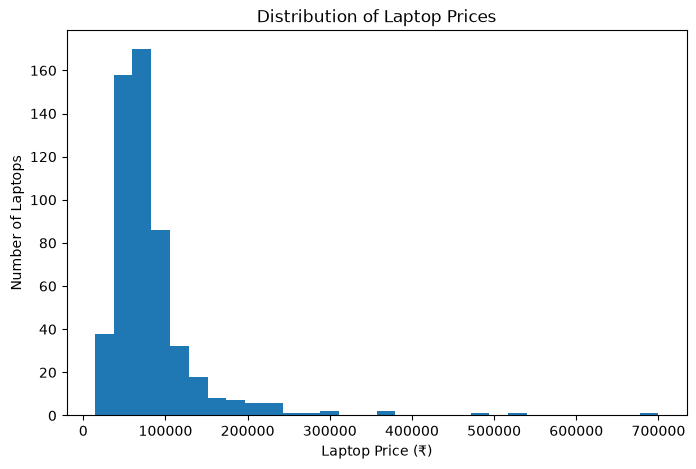

In [184]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["Price"], bins=30)

plt.xlabel("Laptop Price (₹)")
plt.ylabel("Number of Laptops")
plt.title("Distribution of Laptop Prices")

plt.show()

In [185]:
print("Mean Price:", df["Price"].mean())
print("Median Price:", df["Price"].median())

Mean Price: 81649.09293680298
Median Price: 68338.0


## Insights
**Price Distribution**: Laptop prices are right-skewed, with most products concentrated below ₹1 lakh. A small number of premium laptops extend the price range up to approximately ₹7 lakh, causing the mean price (₹81.6K) to exceed the median price (₹68.3K).

## **EDA Step 2 — Price vs RAM**

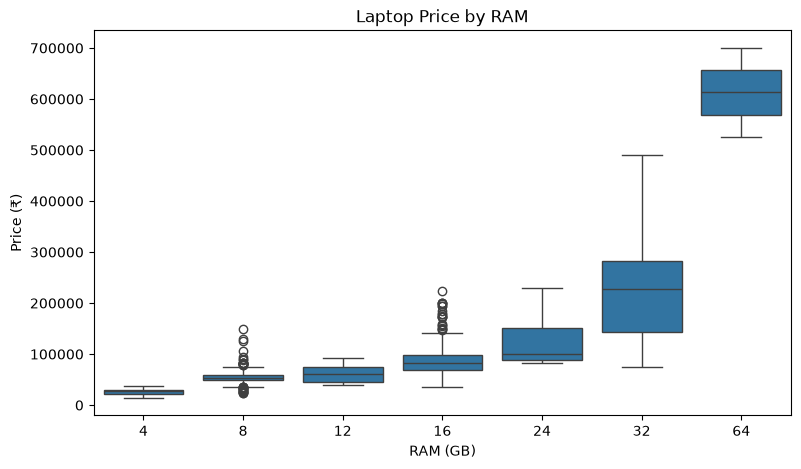

In [187]:
import seaborn as sns
plt.figure(figsize=(9, 5))

sns.boxplot(x="RAM", y="Price", data=df)

plt.xlabel("RAM (GB)")
plt.ylabel("Price (₹)")
plt.title("Laptop Price by RAM")

plt.show()

In [188]:
df.groupby("RAM")["Price"].agg(
    ["count", "mean", "median"]
).sort_index()

,count,mean,median
RAM,,,
4,19,25940.210526,28690.0
8,207,55902.797101,53990.0
12,10,62573.900000,61355.0
16,270,89885.337037,81939.5
24,11,123893.454545,99480.0
32,19,230467.421053,227990.0
64,2,612990.000000,612990.0


## Insights
**Price vs RAM**: There is a clear positive association between RAM and laptop price in this dataset. The median price increases from about ₹28.7K for 4 GB RAM to about ₹228K for 32 GB RAM.

The 64 GB category has only 2 laptops, so we shouldn't generalize that result strongly.

Also notice the outliers for 8 GB and 16 GB. That's interesting because RAM isn't the only factor determining price—processor, brand, GPU, display, etc. can also influence price.

## **EDA Step 3 — Brand vs Price**

In [189]:
brand_counts = df["Brand"].value_counts()

top_brands = brand_counts[brand_counts >= 5].index

brand_price = df[df["Brand"].isin(top_brands)]

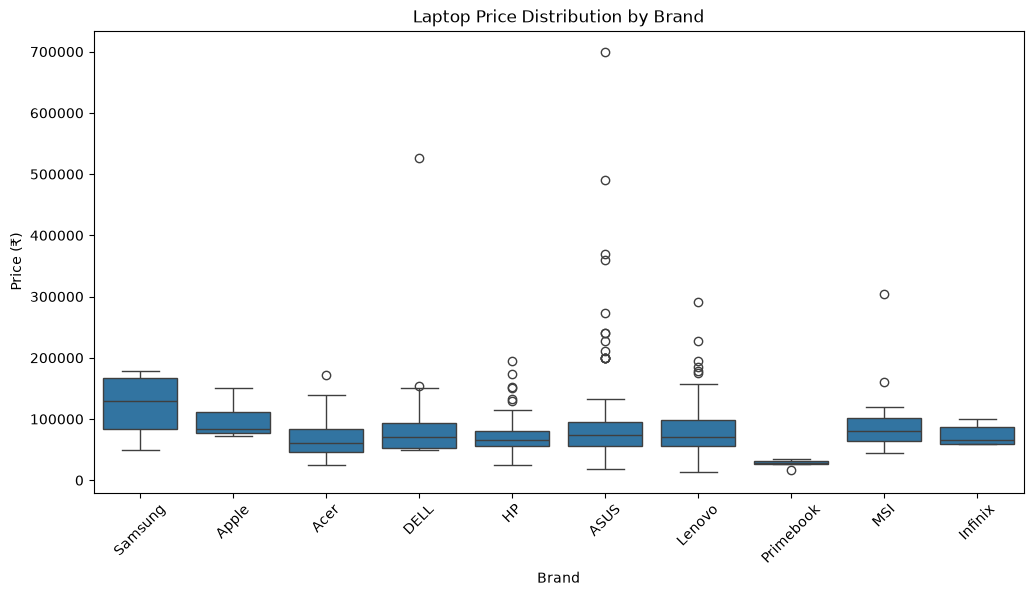

In [190]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    x="Brand",
    y="Price",
    data=brand_price
)

plt.xlabel("Brand")
plt.ylabel("Price (₹)")
plt.title("Laptop Price Distribution by Brand")
plt.xticks(rotation=45)

plt.show()

In [191]:
brand_price.groupby("Brand")["Price"].agg(
    ["count", "mean", "median"]
).sort_values("median", ascending=False)

,count,mean,median
Brand,,,
Samsung,10,123976.600000,129990.0
Apple,7,97977.142857,82990.0
MSI,20,93684.550000,79835.0
ASUS,117,97827.316239,73748.0
Lenovo,85,82916.388235,69990.0
DELL,47,87292.765957,69900.0
HP,130,70768.392308,65895.0
Infinix,8,73116.125000,64994.5
Acer,91,66202.780220,60407.0


## Insights

**Brand vs Price:** There are clear differences in the price distributions across brands in this dataset.

Some examples from your table:

Samsung: median ₹1,29,990
Apple: median ₹82,990
MSI: median ₹79,835
ASUS: median ₹73,748
Lenovo: median ₹69,990
DELL: median ₹69,900
HP: median ₹65,895
Acer: median ₹60,407
Primebook: median ₹28,990

However, we should be careful with brands such as Samsung, Apple, Infinix, and especially Primebook, because their sample sizes are small compared with HP, ASUS, Acer, and Lenovo.

There are also several high-price outliers, particularly within ASUS, DELL, Lenovo, HP, and MSI. These appear as individual points far above the main box distributions.

## **EDA Step 4 — Storage vs Price**

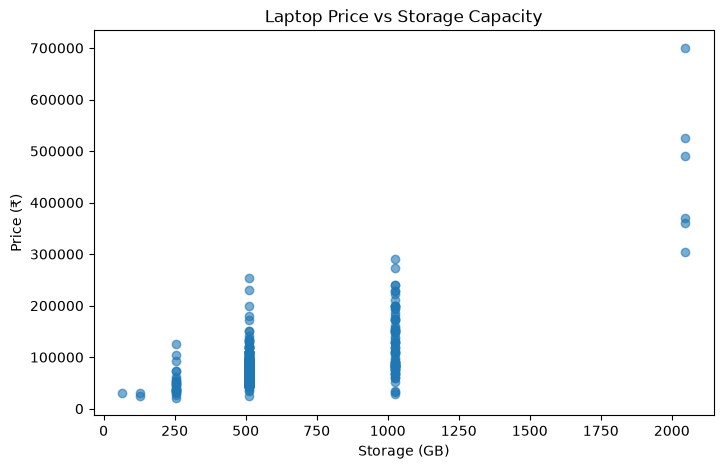

In [192]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Storage_GB"], df["Price"], alpha=0.6)

plt.xlabel("Storage (GB)")
plt.ylabel("Price (₹)")
plt.title("Laptop Price vs Storage Capacity")

plt.show()

In [193]:
df[["Storage_GB", "Price"]].corr()

,Storage_GB,Price
Storage_GB,1.000000,0.714654
Price,0.714654,1.000000


Your correlation is:

Storage_GB vs Price = 0.714654

A correlation of approximately 0.71 indicates a strong positive linear association in this dataset.

The scatter plot also supports this: higher storage capacities tend to occur with higher-priced laptops, although there is considerable variation at each storage level.

For example, many 512 GB and 1 TB laptops have a wide range of prices. So storage alone doesn't determine price.

Portfolio insight

You can write:

Storage vs Price: Storage capacity shows a strong positive association with laptop price, with a correlation of approximately 0.71. However, the wide price variation at similar storage capacities indicates that other specifications also contribute to laptop pricing.


## **EDA Step 5 — Display Size vs Price**

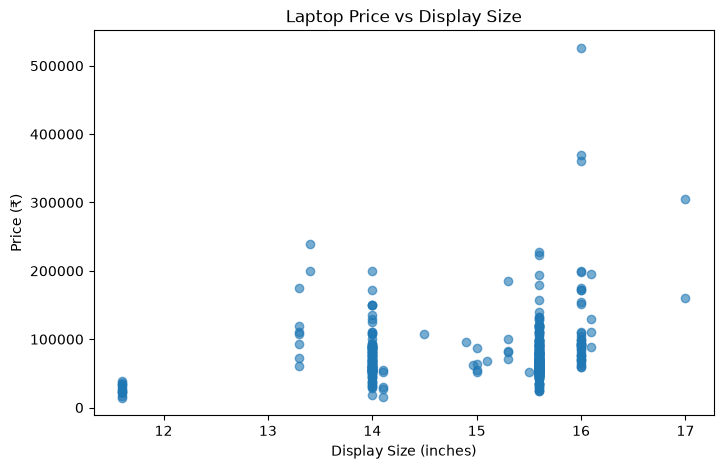

In [194]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Display_Size"], df["Price"], alpha=0.6)

plt.xlabel("Display Size (inches)")
plt.ylabel("Price (₹)")
plt.title("Laptop Price vs Display Size")

plt.show()

In [196]:
df[["Display_Size", "Price"]].corr()

,Display_Size,Price
Display_Size,1.000000,0.193831
Price,0.193831,1.000000


## Insights
**Display Size vs Price:** 
Your correlation is:

Display_Size vs Price = 0.193831

This indicates a weak positive linear relationship between display size and price in your dataset.

The scatter plot supports this: laptops with similar display sizes can have very different prices.

## **EDA Step 6 — Processor vs Price.**

In [199]:
def get_processor_family(processor):
    processor = processor.lower()

    if "core i3" in processor:
        return "Intel Core i3"
    elif "core i5" in processor:
        return "Intel Core i5"
    elif "core i7" in processor:
        return "Intel Core i7"
    elif "core i9" in processor:
        return "Intel Core i9"
    elif "core ultra 3" in processor:
        return "Intel Core Ultra 3"
    elif "core ultra 5" in processor:
        return "Intel Core Ultra 5"
    elif "core ultra 7" in processor:
        return "Intel Core Ultra 7"
    elif "core ultra 9" in processor:
        return "Intel Core Ultra 9"
    elif "ryzen 3" in processor:
        return "AMD Ryzen 3"
    elif "ryzen 5" in processor:
        return "AMD Ryzen 5"
    elif "ryzen 7" in processor:
        return "AMD Ryzen 7"
    elif "ryzen 9" in processor:
        return "AMD Ryzen 9"
    elif "snapdragon" in processor:
        return "Snapdragon"
    elif "celeron" in processor:
        return "Intel Celeron"
    else:
        return "Other"


df["Processor_Family"] = df["Processor"].apply(get_processor_family)

In [200]:
df["Processor_Family"].value_counts()

Processor_Family
Intel Core i5         119
Other                  79
Intel Core i3          71
AMD Ryzen 5            66
Intel Core i7          47
AMD Ryzen 3            37
Intel Celeron          26
AMD Ryzen 7            23
Intel Core Ultra 5     23
Intel Core Ultra 7     18
Snapdragon             17
Intel Core Ultra 9      9
AMD Ryzen 9             3
Name: count, dtype: int64

In [201]:
df.groupby("Processor_Family")["Price"].agg(
    ["count", "mean", "median"]
).sort_values("median", ascending=False)

,count,mean,median
Processor_Family,,,
Intel Core Ultra 9,9,354767.777778,359990.0
AMD Ryzen 9,3,200739.000000,199990.0
Intel Core Ultra 7,18,140317.722222,130994.5
Intel Core i7,47,114000.212766,98890.0
AMD Ryzen 7,23,100079.869565,92246.0
Intel Core Ultra 5,23,87738.826087,88900.0
Snapdragon,17,97771.705882,77016.0
Intel Core i5,119,78153.193277,71200.0
Other,79,79830.151899,69490.0


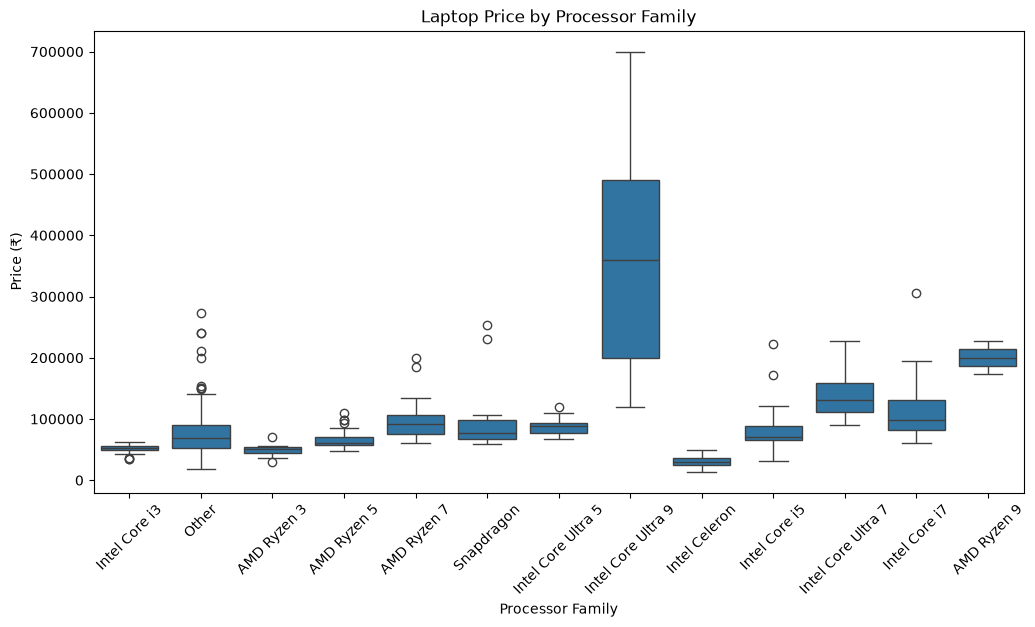

In [202]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    x="Processor_Family",
    y="Price",
    data=df
)

plt.xlabel("Processor Family")
plt.ylabel("Price (₹)")
plt.title("Laptop Price by Processor Family")
plt.xticks(rotation=45)

plt.show()

## Insights

**Processor vs Price:** There is a clear association between processor family and laptop price in your dataset. Higher-end processor families generally appear at higher price levels, while entry-level processors such as Celeron, Ryzen 3, and Core i3 have lower median prices.

However, be careful with categories having very few observations:

AMD Ryzen 9 → 3 laptops
Intel Core Ultra 9 → 9 laptops

So their median prices shouldn't be generalized to the broader laptop market.

## **EDA Step 7 — Operating System vs Price**

In [203]:
os_price = df.dropna(subset=["Operating_System"])

os_price.groupby("Operating_System")["Price"].agg(
    ["count", "mean", "median"]
).sort_values("median", ascending=False)

,count,mean,median
Operating_System,,,
Mac OS,7,97977.142857,82990.0
Windows 11 Home,227,89720.105727,70481.0
Windows 11,261,78866.160920,68338.0
Windows 10,17,84586.352941,65990.0
DOS,1,53697.000000,53697.0
Linux/Ubuntu,2,51450.000000,51450.0
Android,5,28090.000000,28990.0
Chrome,17,28049.117647,28690.0


The Windows 11 and Windows 11 Home categories dominate your dataset, with 261 and 227 laptops respectively. Therefore, they provide much more data for comparison than categories such as DOS or Linux/Ubuntu.

For categories with very small counts—especially DOS, Linux/Ubuntu, Android, and Mac OS—we should be cautious about generalizing their median prices.

Portfolio wording

Operating System vs Price: Laptop prices vary across operating-system categories. Windows 11 and Windows 11 Home account for most observations, while smaller OS categories show different price levels but have limited sample sizes. Therefore, OS-related price differences should be interpreted alongside other specifications.

## **EDA: Correlation Analysis**

In [205]:
numeric_cols = [
    "Price",
    "Rating",
    "Total_Reviews",
    "RAM",
    "Display_Size",
    "Storage_GB",
    "Warranty_Years"
]

correlation = df[numeric_cols].corr()

correlation

,Price,Rating,Total_Reviews,RAM,Display_Size,Storage_GB,Warranty_Years
Price,1.000000,0.245360,-0.186886,0.775758,0.193831,0.714654,0.076553
Rating,0.245360,1.000000,0.025006,0.236417,0.134945,0.146177,0.051501
Total_Reviews,-0.186886,0.025006,1.000000,-0.174182,-0.174584,-0.106750,-0.092620
RAM,0.775758,0.236417,-0.174182,1.000000,0.201649,0.576608,0.061670
Display_Size,0.193831,0.134945,-0.174584,0.201649,1.000000,0.124054,0.055412
Storage_GB,0.714654,0.146177,-0.106750,0.576608,0.124054,1.000000,0.112334
Warranty_Years,0.076553,0.051501,-0.092620,0.061670,0.055412,0.112334,1.000000


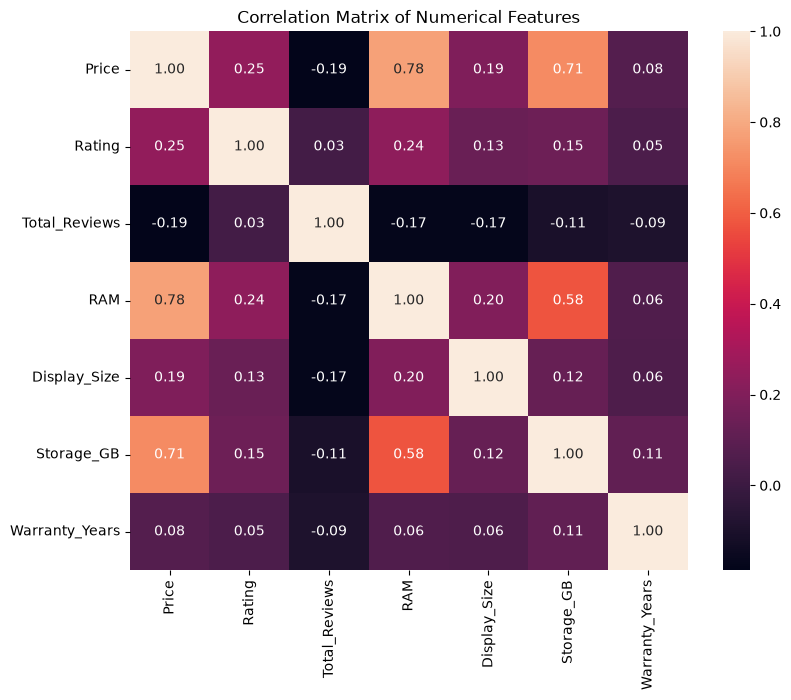

In [206]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

## Insights

**Operating System vs Price**: 

**Key observations**

1. RAM has the strongest numerical relationship with price.

r = 0.776

Higher-RAM laptops in this dataset generally have higher prices.

2. Storage capacity also has a strong relationship with price.

r = 0.715

Laptops with larger storage capacities generally tend to have higher prices.

3. Rating has only a weak relationship with price.

r = 0.245

So customer rating alone doesn't explain much of the variation in laptop prices.

4. Display size has a weak relationship.

r = 0.194

This agrees with the scatter plot we already examined.

5. Warranty years has almost no linear relationship with price.

r = 0.077

6. Total reviews has a weak negative correlation.

r = -0.187

This should not be interpreted as "more reviews cause lower prices." Correlation only describes the relationship in this dataset.

Important finding for your ML project

You now have evidence that some features could be particularly useful for predicting price:

RAM          → 0.776
Storage_GB   → 0.715
Rating       → 0.245
Display_Size → 0.194

But don't remove features just because their individual correlation with Price is low. Categorical variables such as Brand, Processor_Family, and Operating_System can still provide useful predictive information.

Also, correlation measures linear association, not causation.